AGREGACIÓN DIARIA (CON DATOS DEL IVIA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) CARGA
# =========================
df_orig = pd.read_csv("data_clean_interpolated.csv")
df_meteo = pd.read_csv("meteo_clean_interpolated.csv")

df_orig["instante"] = pd.to_datetime(df_orig["instante"], errors="coerce")
df_meteo["instante"] = pd.to_datetime(df_meteo["instante"], errors="coerce")

df_orig = df_orig.dropna(subset=["instante"]).sort_values("instante")
df_meteo = (
    df_meteo.dropna(subset=["instante"])
    .sort_values("instante")
    .drop_duplicates(subset=["instante"], keep="last")
)

# =========================
# 2) AJUSTES DE COLUMNAS
# =========================
df_orig = df_orig.drop(columns=["HA", "TA"], errors="ignore")
df_meteo_sel = df_meteo.drop(columns=["eto", "precipitacion"], errors="ignore")

# =========================
# 3) MERGE
# =========================
df = df_orig.merge(df_meteo_sel, on="instante", how="left")

# =========================
# 4) AGREGACIÓN DIARIA
# =========================
df = df.set_index("instante").sort_index()

# Definimos las columnas numéricas
num_cols = df.select_dtypes(include="number").columns.tolist()

# Diccionario general de agregación: min, mean y max
agg_dict = {c: ["min", "mean", "max"] for c in num_cols}

# ---- Correcciones específicas ----

# 1) radiacion -> queremos SUMA diaria
if "radiacion" in agg_dict:
    agg_dict["radiacion"] = ["sum"]

# 2) litros_arbol es ACUMULADO (escalera) -> guardar último valor
if "litros_arbol" in agg_dict:
    agg_dict["litros_arbol"] = ["last"]

# 3) litros_intervalo es litros por intervalo -> sumar
if "litros_intervalo" in agg_dict:
    agg_dict["litros_intervalo"] = ["sum"]

# 4) evento_riego es binaria -> max indica si hubo riego
if "evento_riego" in agg_dict:
    agg_dict["evento_riego"] = ["max"]

# Agregación diaria
df_daily = df.resample("D").agg(agg_dict)

# Aplanar MultiIndex: var_stat
df_daily.columns = [f"{var}_{stat}" for var, stat in df_daily.columns]
df_daily = df_daily.reset_index()

# =========================
# 5) GUARDAR
# =========================
df.reset_index().to_csv("data_10min_plus_meteo.csv", index=False)
df_daily.to_csv("data_daily_agg.csv", index=False)

print("Guardado:")
print("- data_10min_plus_meteo.csv (10 min, cruzado con meteo)")
print("- data_daily_agg.csv (diario, agg con suma para radiacion y ajustes para riego)")
print("Dimensiones daily:", df_daily.shape)

Guardado:
- data_10min_plus_meteo.csv (10 min, cruzado con meteo)
- data_daily_agg.csv (diario, agg con suma para radiacion y ajustes para riego)
Dimensiones daily: (1895, 35)


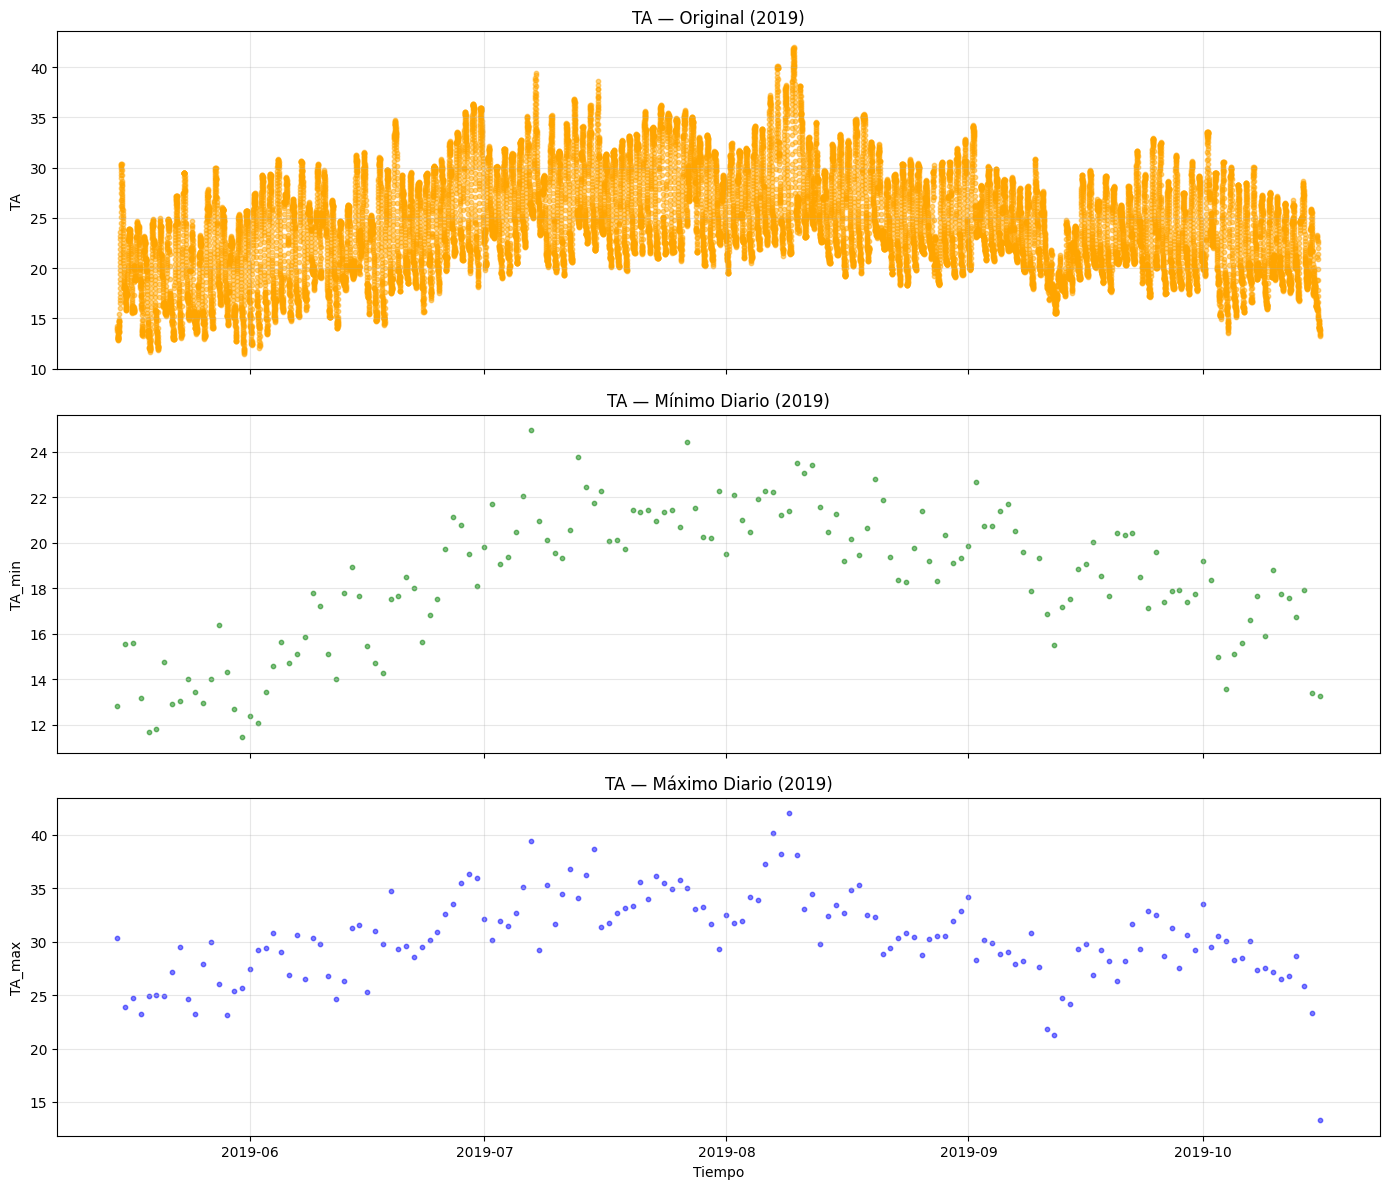

In [2]:
# =========================
# 6) FUNCIÓN PARA GRAFICAR
# =========================
def plot_before_after_aggregation(var, year, df_orig, df_agg):
    """
    Función para graficar los datos antes y después de la agregación diaria de una variable y un año específico.
    
    :param var: Nombre de la variable a graficar (ej. "TA", "precipitacion", "radiacion").
    :param year: Año específico para graficar.
    :param df_orig: DataFrame original con datos sin agregar (con intervalo original, ej. 10min).
    :param df_agg: DataFrame con los datos agregados por día.
    """
    
    # Restablecer el índice de ambos dataframes, asegurándonos de que "instante" sea una columna
    df_orig = df_orig.reset_index()  # Asegura que 'instante' sea una columna
    df_agg = df_agg.reset_index()    # Asegura que 'instante' sea una columna

    # Filtramos los datos por año
    df_before = df_orig[df_orig["instante"].dt.year == year].copy()
    df_after = df_agg[df_agg["instante"].dt.year == year].copy()

    # El nombre de la columna en df_agg será var_stat (por ejemplo, TA_mean, TA_min, TA_max, etc.)
    var_agg_min = f"{var}_min"
    var_agg_mean = f"{var}_mean"
    var_agg_max = f"{var}_max"

    # Creamos los gráficos
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # Primer gráfico: Datos originales (antes de la agregación)
    axes[0].scatter(df_before["instante"], df_before[var], s=10, color='orange', alpha=0.5)
    axes[0].set_title(f"{var} — Original ({year})")
    axes[0].set_ylabel(var)
    axes[0].grid(True, alpha=0.3)

    # Segundo gráfico: Datos agregados por día (mínimo)
    axes[1].scatter(df_after["instante"], df_after[var_agg_min], s=10, color='green', alpha=0.5)
    axes[1].set_title(f"{var} — Mínimo Diario ({year})")
    axes[1].set_ylabel(f"{var}_min")
    axes[1].grid(True, alpha=0.3)

    # Tercer gráfico: Datos agregados por día (máximo)
    axes[2].scatter(df_after["instante"], df_after[var_agg_max], s=10, color='blue', alpha=0.5)
    axes[2].set_title(f"{var} — Máximo Diario ({year})")
    axes[2].set_ylabel(f"{var}_max")
    axes[2].set_xlabel("Tiempo")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Ejemplo de uso para la variable "TA" en el año 2019
plot_before_after_aggregation("TA", 2019, df, df_daily)
